In [ ]:
import os
os.chdir('..')
from trader.trader import Trader

In [12]:
trader = Trader()
trader.add_broker('mt5')    
trader.add_data("EURUSD", start="2025-03-01", end="2025-03-31", granularities="tick")
df = trader.data[0].df
df.count()

Fetching from ABCMeta: EURUSD data from 2025-03-01 to 2025-03-31 with granularity tick and price M


bid       1360904
ask       1360904
volume    1360904
dtype: int64

In [13]:
mean_spread = (df.ask - df.bid).mean()
median_spread = (df.ask - df.bid).median()
print(f"Mean spread: {mean_spread}")
print(f"Median spread: {median_spread}")

median_spread = round(median_spread, 5)
print(f"Rounded median spread: {median_spread}")

Mean spread: 3.193606602669992e-05
Median spread: 2.999999999997449e-05
Rounded median spread: 3e-05


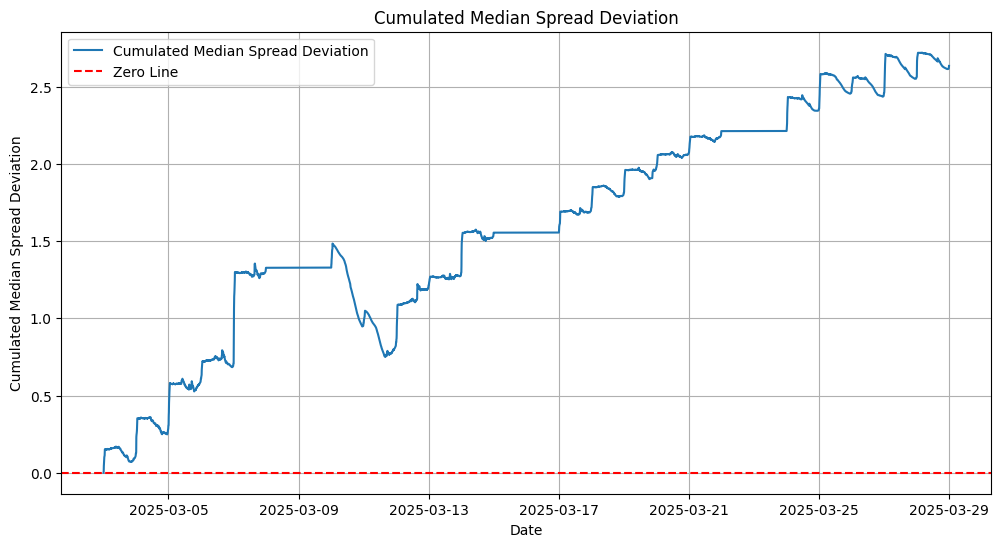

In [14]:
# cumulated median spread deviation
cmsd = (df.ask - df.bid - median_spread).cumsum()

# reset every day, i.e. set cmsd to 0 at the beginning of each day
#cmsd = cmsd - cmsd.groupby(df.index.date).transform('first')

#plot outside of vscode
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df.index, cmsd, label='Cumulated Median Spread Deviation')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Cumulated Median Spread Deviation')
plt.xlabel('Date')
plt.ylabel('Cumulated Median Spread Deviation')
plt.legend()
plt.grid()
plt.show()

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1)

# Add bid and ask line plots to the first subplot
fig.add_trace(
    go.Scatter(x=df.index, y=df['bid'], mode='lines', name='Bid Price', line=dict(color='blue')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df.index, y=df['ask'], mode='lines', name='Ask Price', line=dict(color='red')),
    row=1, col=1
)

# Add cumulative sum plot to the second subplot
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=cmsd,
        mode='lines',
        name='Cumulative Sum',
        line=dict(color='green')
    ),
    row=2, col=1
)

# Update layout
fig.update_layout(
    title='Bid/Ask Prices and Cumulative Sum',
    xaxis=dict(title='Time'),
    xaxis2=dict(title='Time'),
    yaxis=dict(title='Price'),
    yaxis2=dict(title='Cumulative Sum'),
    template='plotly_white',
    height=1000
)

# Show the plot
fig.show(renderer="browser")